# Variants of stochastic gradient-based optimization

In this Notebook I will be demonstrating some different methods to optimize hyperparameters using gradient descent.

First of all, we need to import all the neccessary libraries.

In [92]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.linalg import inv
import time

np.random.seed(42)

After that is done, we generate our data. In our case we want to optimize our model to find the function
$$f(x_1, x_2) = 20x_1 - 3x_2.$$
Here we create this function and add some noise to it.

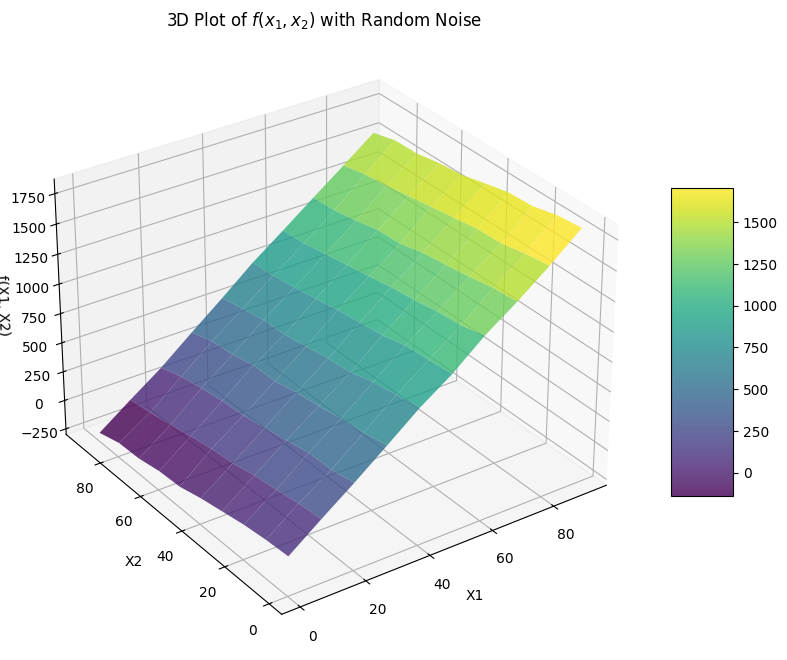

(<Figure size 1000x800 with 2 Axes>,
 <Axes3D: title={'center': '3D Plot of $f(x_1, x_2)$ with Random Noise'}, xlabel='X1', ylabel='X2', zlabel='f(X1, X2)'>)

In [93]:
# Function y = 20*x1 - 3*x2
N = 100
a10 = 20
a20 = -3

# Create grid of points
X1 = np.arange(1, N+1)
X2 = np.arange(1, N+1)
XX = np.array(np.meshgrid(X1, X2)).T.reshape(-1, 2)

# Add random noise
R = np.random.normal(0, 10, N*N)
Y = a10 * XX[:, 0] + a20 * XX[:, 1] + R

# Plot the function
step = max(1, N // 10)
A, B = np.meshgrid(np.arange(1, N+1, step), np.arange(1, N+1, step))

def f0(x1, x2):
    return a10 * x1 + a20 * x2

def f(x1, x2, r):
    return a10 * x1 + a20 * x2 + r

# Function that includes random noise
def ff(x1, x2):
    return f(x1, x2, np.random.normal(0, 10))

# Plot the function
def plot3d(func, X, Y, show_plot=True):
    """
    Create a 3D surface plot
    func: function to evaluate at each point
    X, Y: meshgrid arrays
    show_plot: whether to display the plot
    """
    Z = np.array([[func(x, y) for x, y in zip(row_X, row_Y)] 
                  for row_X, row_Y in zip(X, Y)])
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
    
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('f(X1, X2)')
    ax.set_title(f'3D Plot of $f(x_1, x_2)$ with Random Noise')
    
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
    ax.view_init(elev=30, azim=235)
    
    if show_plot:
        plt.show()
    
    return fig, ax

# Create the plot
plot3d(ff, A, B, show_plot=True)

### Here I define some helper functions to use later on

In [94]:
def mse(ws, m, X, Y):
    """Mean squared error loss function"""
    N = len(X)
    predictions = np.array([m(ws, X[i]) for i in range(N)])
    return np.mean((Y - predictions) ** 2)

def grad_mse(ws, m, gradients, X, Y):
    """Gradient of mean squared error"""
    N = len(X)
    grad = np.zeros(len(ws))
    for i in range(N):
        xi = X[i]
        yi = Y[i]
        diff = yi - m(ws, xi)
        for j in range(len(ws)):
            grad[j] += diff * gradients[j](ws, xi)
    return -2/N * grad

def grad_desc_mse(K, ws, learning_eps, loss, grad_loss, verbose=False):
    """Gradient descent optimization"""
    history = [loss(ws)]
    for k in range(K):
        grad_ws = grad_loss(ws)
        old_ws = ws.copy()
        ws = old_ws - learning_eps * grad_ws
        if verbose:
            plt.plot([old_ws[0], ws[0]], [old_ws[1], ws[1]], 'b-')
        history.append(loss(ws))
    return ws, history

### Defining our simple linear model and weight initialization

Here I define the simple one neuron model with no activation with the standard glorot weight initialization.

In [95]:
# Model: linear neural network
m1 = lambda ws, x: ws[0] * x[0] + ws[1] * x[1]
mse1 = lambda ws: mse(ws, m1, XX, Y)

# Glorot uniform initializer
in_units = 2
out_units = 1
limit = np.sqrt(6 / (in_units + out_units))
ws0 = np.array([np.random.rand() * 2 * limit - limit, 
                np.random.rand() * 2 * limit - limit])

print("Initial weights:", ws0)
print("Initial MSE:", mse1(ws0))

# Gradients for the model
gradients1 = [
    lambda ws, x: x[0],
    lambda ws, x: x[1]
]

# Loss gradients
grad_loss = lambda ws: grad_mse(ws, m1, gradients1, XX, Y)
grad_loss2 = lambda ws, randices: grad_mse(ws, m1, gradients1, XX[randices], Y[randices])

Initial weights: [0.12077737 0.84572904]
Initial MSE: 997160.8985653088


I will also add the plotting tool here to help visualize the learning later from now on.

In [96]:
def setup_plot():
    """Setup the 3D plot for optimization visualization"""
    A, B = np.meshgrid(np.arange(min(a10, ws0[0])-10, max(a10, ws0[0])+11, 1),
                       np.arange(min(a20, ws0[1])-10, max(a20, ws0[1])+11, 1))
    
    Z = np.array([[mse1([A[i,j], B[i,j]]) for j in range(A.shape[1])] for i in range(A.shape[0])])
    
    fig = plt.figure(figsize=(12, 5))
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot_surface(A, B, Z, cmap='viridis', alpha=0.7)
    ax1.scatter([a10], [a20], [mse1([a10, a20])], color='red', marker='*', s=100)
    ax1.scatter([ws0[0]], [ws0[1]], [mse1(ws0)], color='red', marker='+', s=100)
    ax1.set_xlabel('w1')
    ax1.set_ylabel('w2')
    ax1.set_zlabel('MSE')
    
    ax2 = fig.add_subplot(122)
    contour = ax2.contour(A, B, Z, levels=30, cmap='viridis')
    ax2.plot(a10, a20, '*r', markersize=10)
    ax2.plot(ws0[0], ws0[1], '+r', markersize=10)
    ax2.set_xlabel('w1')
    ax2.set_ylabel('w2')
    plt.colorbar(contour, ax=ax2)
    
    return ax2

### Vanilla gradient descent

To show that all is fine we perform a regular gradient descent.

Time: 1.296967 seconds
Final weights: [19.90423419 -3.01680753]
Final MSE: 140.09498557625054


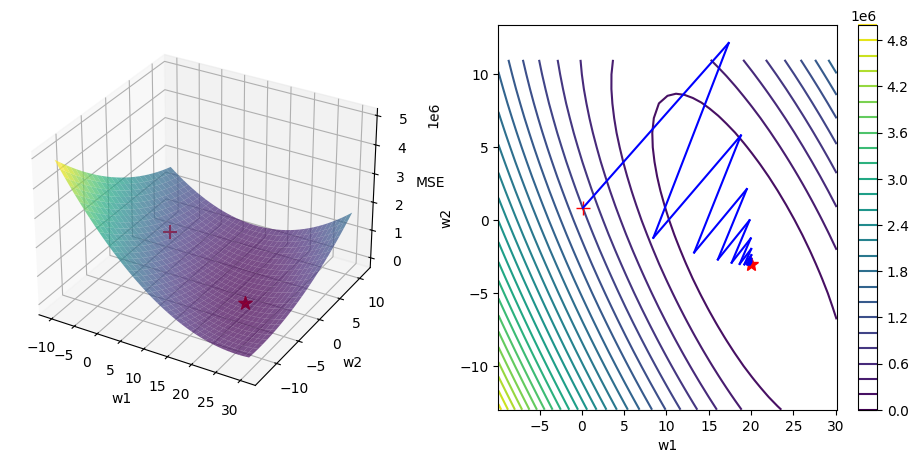

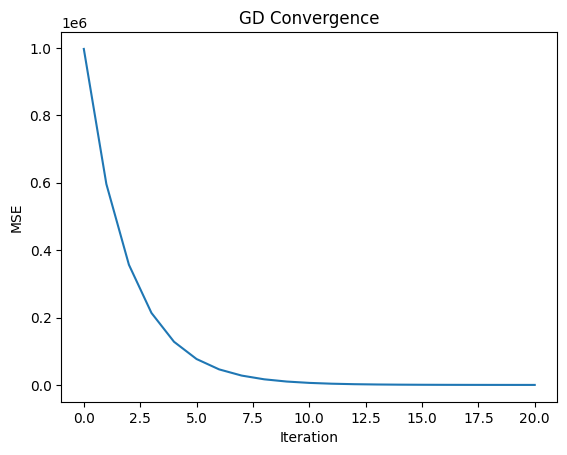

In [97]:
K = 20
learning_eps = 0.00015

ax = setup_plot()
start_time = time.time()
ws_gd, history_gd = grad_desc_mse(K, ws0.copy(), learning_eps, mse1, grad_loss, verbose=True)
print(f"Time: {time.time() - start_time:.6f} seconds")
print(f"Final weights: {ws_gd}")
print(f"Final MSE: {history_gd[-1]}")
plt.show()

plt.figure()
plt.plot(range(len(history_gd)), history_gd)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('GD Convergence')
plt.show()

## Stochastic Gradient Descent

First on the agenda is the faster, random gradient descent, aka 'Stochastic' Gradient Descent.

This works by computing smaller subsets (batches) of the complete dataset of samples to take more frequent/smaller steps per epoch instead of one singular calculated step.

In [98]:
def stochastic_grad_desc_mse(K, ws, learning_eps, loss, grad_loss, N, verbose=False):
    """Stochastic Gradient Descent"""
    batch_size = int(N * 0.01)
    history = [loss(ws)]
    for k in range(K):
        randices = np.random.choice(N, batch_size, replace=False)
        grad_ws = grad_loss(ws, randices)
        old_ws = ws.copy()
        ws = old_ws - learning_eps * grad_ws
        if verbose:
            plt.plot([old_ws[0], ws[0]], [old_ws[1], ws[1]], 'b-')
        history.append(loss(ws))
    return ws, history

Time: 0.385017 seconds
Final weights: [19.91271846 -3.00877633]
Final MSE: 129.92347592520105


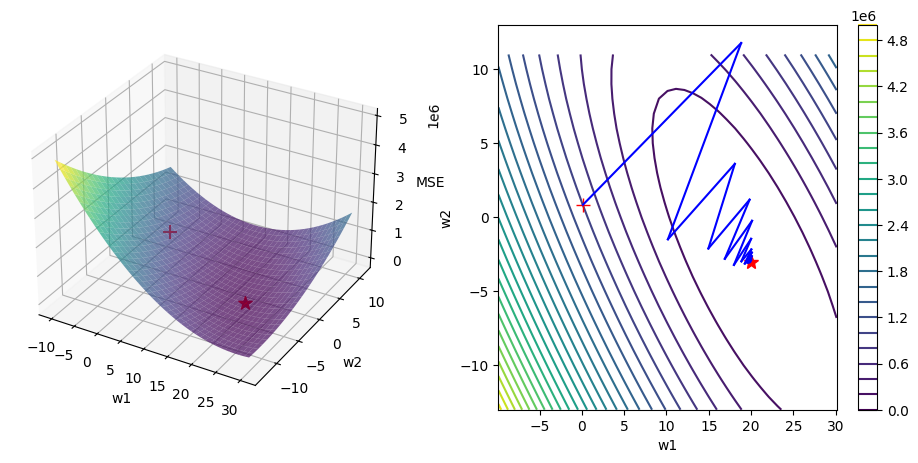

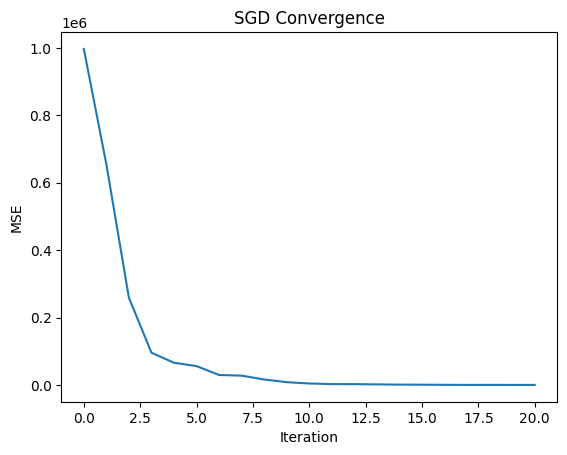

In [99]:
K = 20
learning_eps = 0.00015

ax = setup_plot()
start_time = time.time()
ws_sgd, history_sgd = stochastic_grad_desc_mse(K, ws0.copy(), learning_eps, mse1, grad_loss2, N*N, verbose=True)
print(f"Time: {time.time() - start_time:.6f} seconds")
print(f"Final weights: {ws_sgd}")
print(f"Final MSE: {history_sgd[-1]}")
plt.show()

plt.figure()
plt.plot(range(len(history_sgd)), history_sgd)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('SGD Convergence')
plt.show()

## SGD with adaptive learning rate

Next up is the same thing but here we update the learning rate $\epsilon$ every epoch by

$$\epsilon_{k+1} = \epsilon_{k}\cdot(1-\alpha), \space \alpha \in [0, 1)$$

Here a larger $\alpha$ (closer to 1) means a more aggressive shrinking of the learning rate and in turn a slower convergence, while a smaller $\alpha$ might cause us to step over the local/global minima and cause us to end up in a local instead of a global minima.

In [100]:
def stochastic_adaptive_grad_desc_mse(K, ws, learning_eps, loss, grad_loss, N, alpha, verbose=False):
    """SGD with adaptive learning rate"""
    batch_size = int(N * 0.01)
    history = [loss(ws)]
    for k in range(K):
        randices = np.random.choice(N, batch_size, replace=False)
        grad_ws = grad_loss(ws, randices)
        old_ws = ws.copy()
        ws = old_ws - learning_eps * grad_ws
        learning_eps = (1 - alpha) * learning_eps
        if verbose:
            plt.plot([old_ws[0], ws[0]], [old_ws[1], ws[1]], 'b-')
        history.append(loss(ws))
    return ws, history

Time: 0.385755 seconds


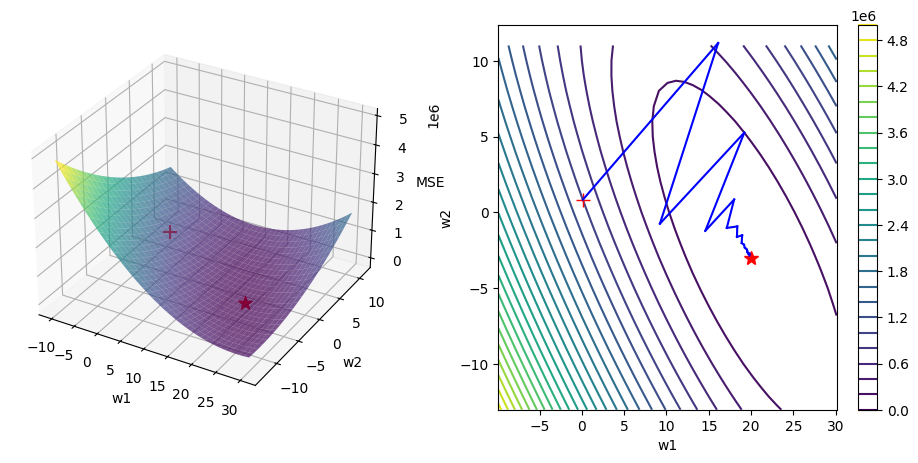

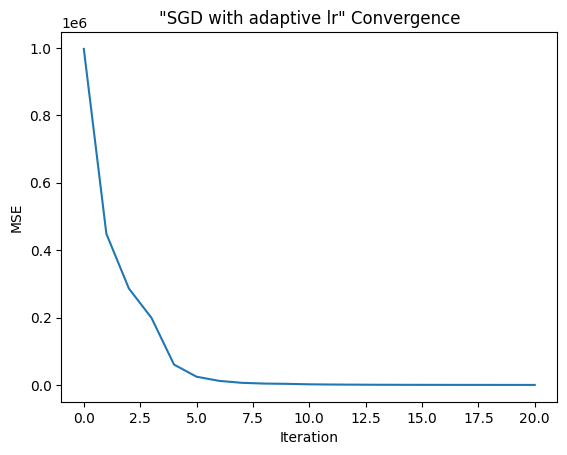

In [101]:
K = 20
learning_eps = 0.00015

ax = setup_plot()
alpha = 0.03
start_time = time.time()
ws_adaptive, history_adaptive = stochastic_adaptive_grad_desc_mse(K, ws0.copy(), learning_eps, mse1, grad_loss2, N*N, alpha, verbose=True)
print(f"Time: {time.time() - start_time:.6f} seconds")
plt.show()

plt.figure()
plt.plot(range(len(history_adaptive)), history_adaptive)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('\"SGD with adaptive lr\" Convergence')
plt.show()

## SGD with momentum

Now we introduce 'momentum'.

This is trying to stop the optimization from 'zig-zagging' too much and keep the learning going 'downhill'.

As in regular mechanics, **momentum** is defined as **mass** times **velocity**, and so it shall remain in our case.

Here we use our gradient as our velocity and the new hyperparameter $m$ is thus the mass of the imaginary person walking along the gradient descent.

$$\epsilon_{k+1} = \epsilon_{k}\cdot\nabla J(\theta)\cdot m$$

A heavier person (i.e. a larger mass) leads to less correction ater each step and a good rule of thumb is to leave the initial learning rate small to avoid accruing too much momentum and missing completely.

In [102]:
def stochastic_momentum_grad_desc_mse(K, ws, learning_eps, loss, grad_loss, N, mass, verbose=False):
    """SGD with momentum"""
    batch_size = int(N * 0.01)
    history = [loss(ws)]
    v = 0
    for k in range(K):
        randices = np.random.choice(N, batch_size, replace=False)
        grad_ws = grad_loss(ws, randices)
        v = (v + grad_ws) / 2
        old_ws = ws.copy()
        ws = old_ws - mass * v - learning_eps * grad_ws
        if verbose:
            plt.plot([old_ws[0], ws[0]], [old_ws[1], ws[1]], 'b-')
        history.append(loss(ws))
    return ws, history

Time: 0.386638 seconds


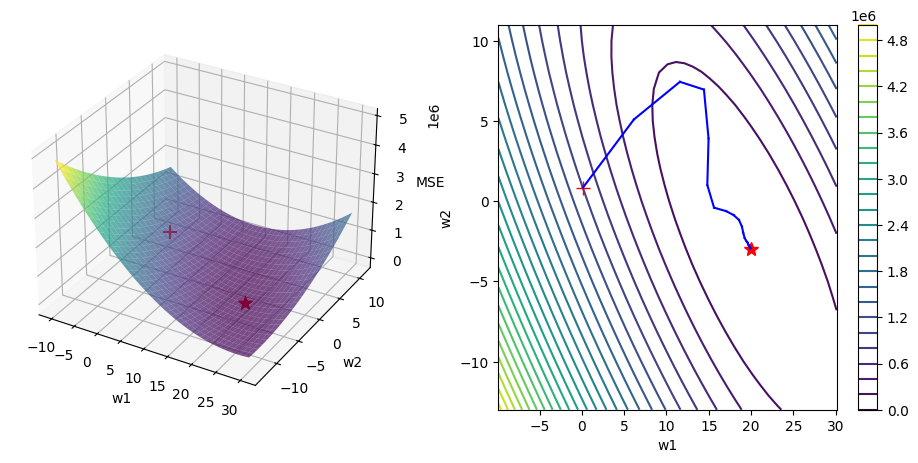

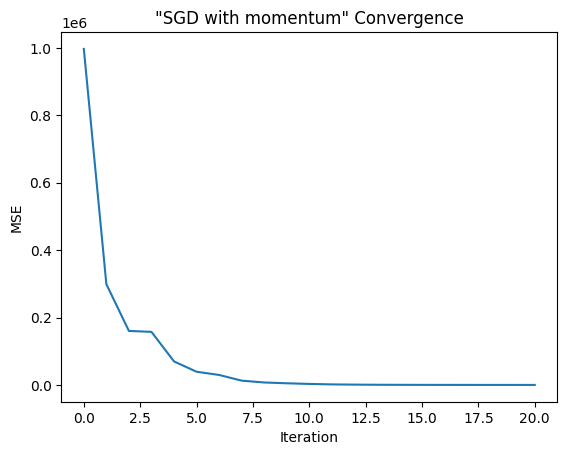

In [103]:
K = 20
learning_eps = 0.00001

ax = setup_plot()
mass = 0.0001
start_time = time.time()
ws_momentum, history_momentum = stochastic_momentum_grad_desc_mse(
    K, ws0.copy(), learning_eps, mse1, grad_loss2, N*N, mass, verbose=True)
print(f"Time: {time.time() - start_time:.6f} seconds")
plt.show()

plt.figure()
plt.plot(range(len(history_momentum)), history_momentum)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('\"SGD with momentum\" Convergence')
plt.show()

## SGD with accumulated squared gradient: AdaGrad

Now on to something new, Adaptive Gradient, AdaGrad.

This method adapts the learning rate for each parameter depending on how steep the gradient is and the 'history' of it's gradients, implementing a sum of squares of past gradients for that parameter.

Assume parameter $\theta_i$ at epoch $t$, then the update looks like this:

$$\theta_{t+1,i} = \theta_{t,i} - \frac{\epsilon}{\sqrt{\sum_{\tau} g_{\tau,i}^2 + \delta}}\cdot g_{t,i},$$

where $g_{t,i}$ is the gradient of parameter $\theta_i$ at epoch $t$ and $\delta$ is a small smoothing constant.

Here the stagnation of the learning rate is quite fast so even with an initail learning rate of 25, we just barely arrive at the minima in 20 epochs.

In [116]:
def ada_grad_mse(K, ws, learning_eps, loss, grad_loss, N, verbose=False):
    """AdaGrad optimizer"""
    batch_size = int(N * 0.01)
    history = [loss(ws)]
    r = np.zeros(len(ws))
    delta = 1e-10 * np.ones(len(ws))
    for k in range(K):
        randices = np.random.choice(N, batch_size, replace=False)
        grad_ws = grad_loss(ws, randices)
        old_ws = ws.copy()
        r = r + grad_ws * grad_ws
        ws = old_ws - learning_eps / (delta + np.sqrt(r)) * grad_ws
        if verbose:
            plt.plot([old_ws[0], ws[0]], [old_ws[1], ws[1]], 'b-')
        history.append(loss(ws))
    return ws, history

Time: 0.388162 seconds


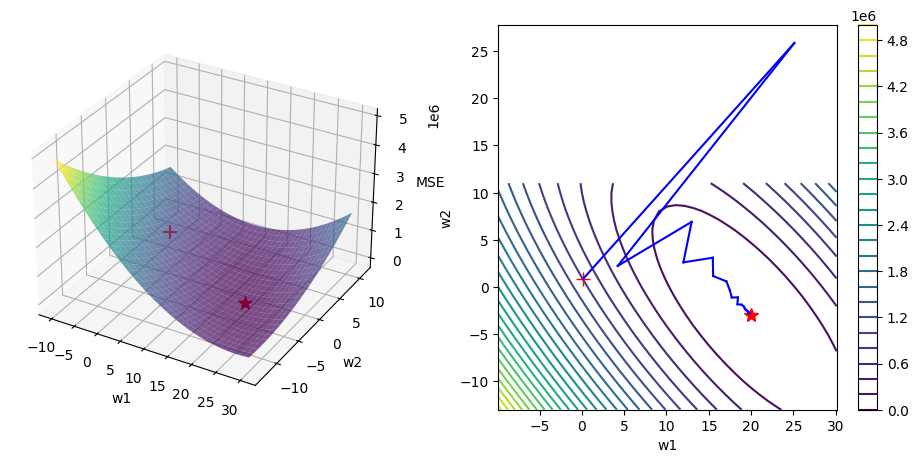

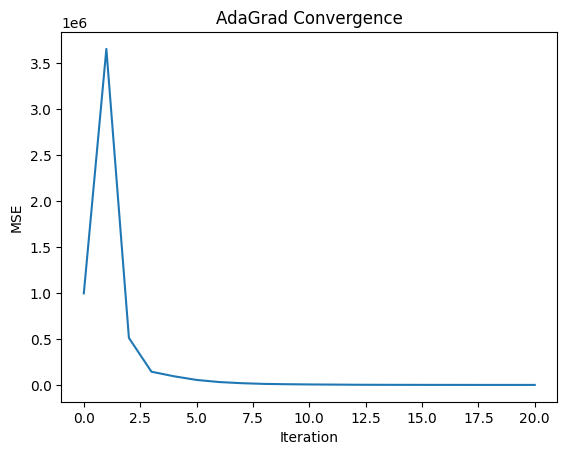

In [117]:
K = 20
learning_eps = 25

ax = setup_plot()
start_time = time.time()
ws_ada, history_ada = ada_grad_mse(K, ws0.copy(), learning_eps, mse1, grad_loss2, N*N, verbose=True)
print(f"Time: {time.time() - start_time:.6f} seconds")
plt.show()

plt.figure()
plt.plot(range(len(history_ada)), history_ada)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('AdaGrad Convergence')
plt.show()

## SGD with accumulated squared gradient: RMSProp

This time we try Root Mean Square Propagation, RMSProp.

This method is designed to counter the fatal flaw of AdaGrad, stagnating learning rate for larger numbers of epochs. This is done by adding the hyperparameter $\rho \in [0, 1]$, being a bias to decide how much the next learning rate should depend on the squared sum of gradients and just the last step.

So instead of simply adding the squares,
$$r_{k+1} = r_k + g^2,$$
we now add the bias term $\rho$,
$$r_{k+1} = r_k\cdot\rho + (1 - \rho)\cdot g^2.$$

Here we see a similar case as with the AdaGrad, the stagnation of the learning rate is quite fast, so to counter this we lower $\rho$ to lean more into forgetting the past 'history' and arrive at a more constant learning rate. This however does not help us in this simple case and results in us not arriving at the minima.

In [106]:
def rms_prob_mse(K, ws, learning_eps, loss, grad_loss, N, rho, verbose=False):
    """RMSProp optimizer"""
    batch_size = int(N * 0.01)
    history = [loss(ws)]
    r = np.zeros(len(ws))
    delta = 1e-10 * np.ones(len(ws))
    for k in range(K):
        randices = np.random.choice(N, batch_size, replace=False)
        grad_ws = grad_loss(ws, randices)
        old_ws = ws.copy()
        r = rho * r + (1 - rho) * grad_ws * grad_ws
        ws = old_ws - learning_eps / (np.sqrt(delta + r)) * grad_ws
        if verbose:
            plt.plot([old_ws[0], ws[0]], [old_ws[1], ws[1]], 'b-')
        history.append(loss(ws))
    return ws, history

Time: 0.388347 seconds


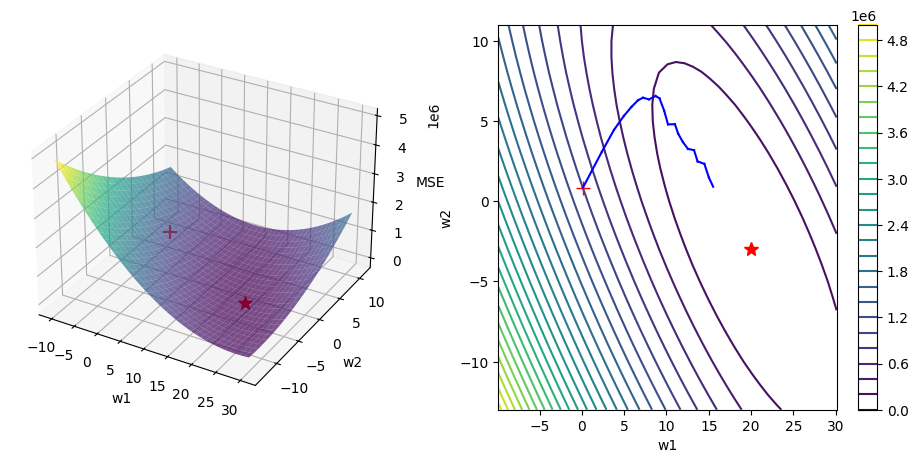

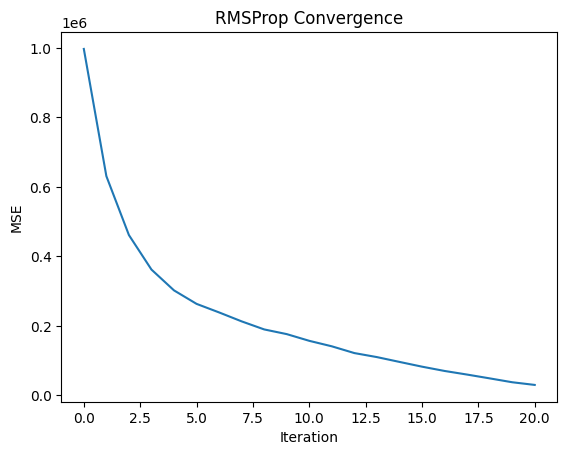

In [118]:
K = 20
learning_eps = 1

ax = setup_plot()
rho = 0.80
start_time = time.time()
ws_rms, history_rms = rms_prob_mse(K, ws0.copy(), learning_eps, mse1, grad_loss2, N*N, rho, verbose=True)
print(f"Time: {time.time() - start_time:.6f} seconds")
plt.show()

plt.figure()
plt.plot(range(len(history_rms)), history_rms)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('RMSProp Convergence')
plt.show()

## SGD with accumulated squared gradient: ADAM

The last accumulated squared gradient version to try here is ADAM, Adaptive Moment Estimation.

This is the method to use when you want the statbility of momentum and the magnitude from RMSProp. ADAM combines these two methods with one slight twist, the mass hyperparameter $m$ from momentum is now set to 1 and we now controll the velocity with $\rho_1 \in [0, 1]$ to compute how much of the past momentum we want to consider in our next step. Similarily, the RMSProp hyperparameter is now called $\rho_2 \in [0, 1]$.

Since velocity and momentum are both initialized as 0, they are both biased towards 0, so we must correct this by

$$\hat s = \frac{s}{1 - \rho_1}, \hat r = \frac{r}{1 - \rho_2}.$$

For our simple problem this looks to be overkill since we have to lower $\rho_1$ and $\rho_2$ very much to get any meaningful convergence in 20 epochs.

In [119]:
def adam_mse(K, ws, learning_eps, loss, grad_loss, N, rho1, rho2, verbose=False):
    """ADAM optimizer"""
    batch_size = int(N * 0.01)
    history = [loss(ws)]
    s = np.zeros(len(ws))
    r = np.zeros(len(ws))
    t = 0
    delta = 1e-10 * np.ones(len(ws))
    for k in range(K):
        randices = np.random.choice(N, batch_size, replace=False)
        grad_ws = grad_loss(ws, randices)
        old_ws = ws.copy()
        t += 1
        s = rho1 * s + (1 - rho1) * grad_ws
        r = rho2 * r + (1 - rho2) * grad_ws * grad_ws
        s_hat = s / (1 - rho1**t)
        r_hat = r / (1 - rho2**t)
        ws = old_ws - (learning_eps * s_hat) / (delta + np.sqrt(r_hat))
        if verbose:
            plt.plot([old_ws[0], ws[0]], [old_ws[1], ws[1]], 'b-')
        history.append(loss(ws))
    return ws, history

Time: 0.388774 seconds


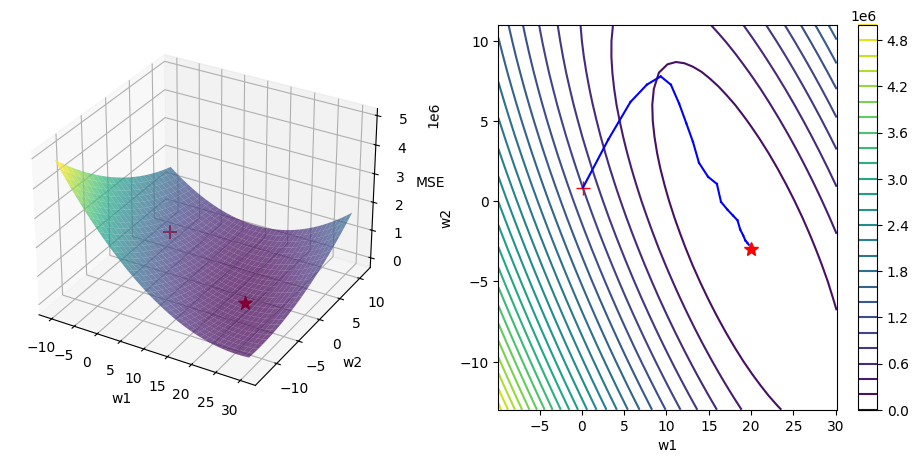

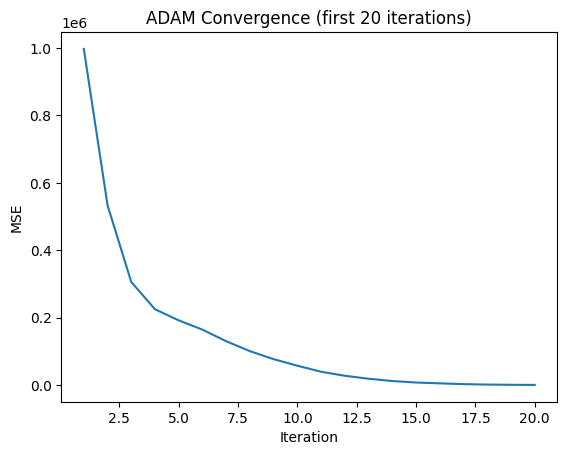

In [136]:
K = 20
learning_eps = 3

ax = setup_plot()
rho1 = 0.30
rho2 = 0.90
start_time = time.time()
ws_adam, history_adam = adam_mse(K, ws0.copy(), learning_eps, mse1, grad_loss2, N*N, rho1, rho2, verbose=True)
print(f"Time: {time.time() - start_time:.6f} seconds")
plt.show()

plt.figure()
plt.plot(range(1, 21), history_adam[:20])
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('ADAM Convergence (first 20 iterations)')
plt.show()

## SGD with Newton’s method

Next up, a more analytical solution to our optimization problem, namely the Newton method.

These solutions rely on the computed matrix $H$, the hessian of the loss function, to be invertible, which it should be, bit can be very computationally expensive to compute.

This method is very similar to the regular Newton method, except here we only use a subset of the samples to compute the hessian $H$.

In our simple case, this is the clear winner in terms of speed since the hessian is only $N\cdot N$, but this can quickly become the slowest method since the complexity increases by $O(N^2)$.

In [137]:
def stochastic_newton_mse(K, ws, loss, grad_loss, grad2_loss, N, verbose=False):
    """Stochastic Newton's method"""
    batch_size = int(N * 0.01)
    history = [loss(ws)]
    for k in range(K):
        randices = np.random.choice(N, batch_size, replace=False)
        grad_ws = grad_loss(ws, randices)
        old_ws = ws.copy()
        H = grad2_loss(ws, randices)
        ws = old_ws - inv(H) @ grad_ws
        if verbose:
            plt.plot([old_ws[0], ws[0]], [old_ws[1], ws[1]], 'b-')
        history.append(loss(ws))
    return ws, history

def hessian_mse(ws, X):
    """Compute Hessian matrix for MSE"""
    N = len(X)
    M = len(ws)
    H = np.zeros((M, M))
    for r in range(M):
        for c in range(M):
            for i in range(N):
                H[r, c] += X[i, r] * X[i, c]
    return 2/N * H

Time: 0.040028 seconds


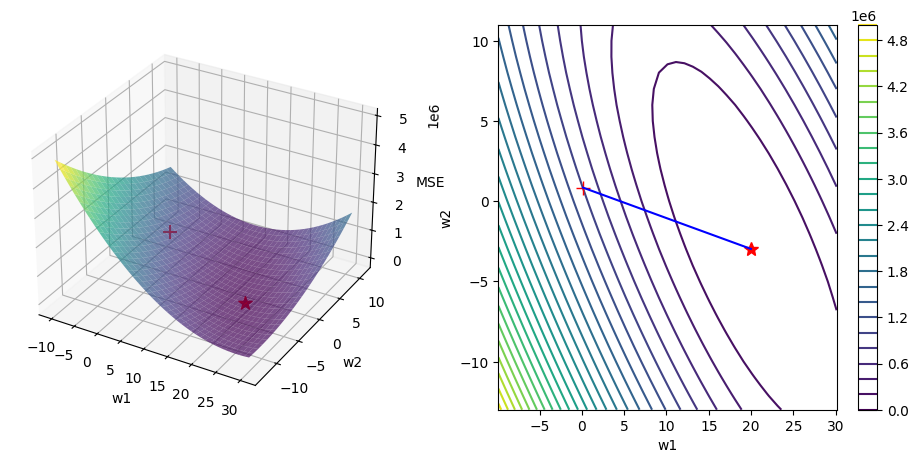

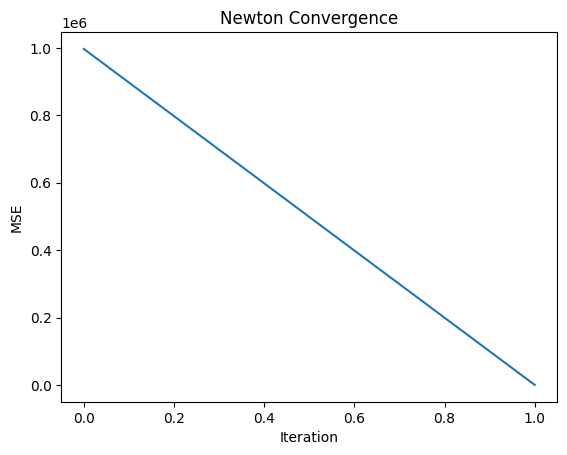

In [138]:
K = 1

grad2_loss = lambda ws, randices: hessian_mse(ws, XX[randices])

ax = setup_plot()
start_time = time.time()
ws_newton, history_newton = stochastic_newton_mse(K, ws0.copy(), mse1, grad_loss2, grad2_loss, N*N, verbose=True)
print(f"Time: {time.time() - start_time:.6f} seconds")
plt.show()

plt.figure()
plt.plot(range(len(history_newton)), history_newton)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Newton Convergence')
plt.show()